<figure>
    <picture>
        <source srcset="../assets/jii-logo.png" style="max-height: 10rem;">
        <img src="https://raw.githubusercontent.com/Computational-Biology-Aachen/2026-photosynthesis-hackathon-template/refs/heads/main/assets/jii-logo.png" style="max-height: 10rem;">
    </picture>
</figure>

# ML prediction — Grebbedijk potato

Machine learning models for predicting photosynthesis phenotypes from MultispeQ measurements.

|                        |                                   |
| ---------------------- | --------------------------------- |
| **Dataset**            | Grebbedijk potato (3,681 measurements) |
| **Protocol**           | UNZA_PIRK_DIRK_LightPotential_14 |
| **Scalar features**    | PAR, temperature, SPAD, PIRK, autogain |
| **Trace features**     | PAM-ABS fluorescence (660 points) |
| **Targets**            | Phi2 (quantum yield of PSII)      |

**Approach:**

1. **Ridge / Lasso baseline** — does a linear model already explain the target?
2. **HistGradientBoosting** — best first bet for scalar features, handles missing values natively
3. **RandomForest** — robust second opinion, less prone to overfitting on small datasets
4. **PLS Regression** — designed for high-dimensional correlated inputs (fluorescence traces)
5. **Ridge / Lasso on traces** — which time points in the fluorescence curve matter most?

In [33]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATA = Path("..") / "data"
df = pl.read_parquet(DATA / "grebbedijk_measurements.parquet")
print(f"Loaded {df.height} measurements, {df.width} columns")

Loaded 3681 measurements, 52 columns


## Part 1 — Scalar features → Phi2

Predict `phi2_ambient` (quantum yield of PSII under ambient light) from the other
scalar features: PAR, temperature, SPAD, PIRK amplitudes, autogain calibration values.

We deliberately exclude `phi2_high`, `LEF_ambient`, `LEF_high`, `LEF_light_potential` —
these are directly derived from or co-measured with `phi2_ambient` and would leak the target.

In [34]:
# Feature matrix: environmental + calibration features (no leakage)
feature_cols = [
    "PAR",
    "SPAD",
    "ambient_Temperature",
    "leaf_temperature",
    "leaf_temperature_differential",
    "humidity",
    "pressure",
    "leaf_angle",
    "PIRK_amp_ambient",
    "PIRK_amp_high",
    "pirk_intensity",
    "autogain_ch1_duration",
    "autogain_ch1_intensity",
    "autogain_ch1_value",
    "autogain_ch2_duration",
    "autogain_ch2_intensity",
    "autogain_ch2_value",
    "measurement_duration_sec",
]

X_scalar = df.select(feature_cols).to_numpy()
y = df["phi2_ambient"].to_numpy()

print(f"X_scalar shape: {X_scalar.shape}")
print(f"y range: [{y.min():.3f}, {y.max():.3f}], mean: {y.mean():.3f}")

X_scalar shape: (3681, 18)
y range: [0.022, 0.643], mean: 0.338


### Ridge / Lasso baseline

Before anything fancy, fit a linear model. If Ridge already explains 80% of variance,
the relationship is mostly linear and complex models aren't needed. Lasso tells us
which features matter most (zero coefficients = irrelevant features).

In [35]:
# Ridge regression with built-in cross-validation for alpha selection
ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]),
)
ridge_scores = cross_val_score(ridge, X_scalar, y, cv=5, scoring="r2")
print(f"Ridge R² (5-fold CV): {ridge_scores.mean():.3f} ± {ridge_scores.std():.3f}")

# Lasso for feature selection
lasso = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, max_iter=10_000),
)
lasso_scores = cross_val_score(lasso, X_scalar, y, cv=5, scoring="r2")
print(f"Lasso R² (5-fold CV): {lasso_scores.mean():.3f} ± {lasso_scores.std():.3f}")

# Fit Lasso on full data to inspect coefficients
lasso.fit(X_scalar, y)
lasso_coefs = lasso.named_steps["lassocv"].coef_

print("\nLasso feature importance (non-zero coefficients):")
for name, coef in sorted(
    zip(feature_cols, lasso_coefs), key=lambda x: abs(x[1]), reverse=True
):
    if abs(coef) > 1e-6:
        print(f"  {name:40s} {coef:+.4f}")

Ridge R² (5-fold CV): 0.749 ± 0.103
Lasso R² (5-fold CV): 0.749 ± 0.093

Lasso feature importance (non-zero coefficients):
  PAR                                      -0.1109
  humidity                                 +0.0069
  autogain_ch1_intensity                   -0.0059
  SPAD                                     +0.0052
  leaf_temperature_differential            -0.0045


### HistGradientBoosting

Gradient boosted trees: fast, handles mixed feature types, needs minimal tuning.
With a small dataset, conservative settings (low learning rate, moderate depth,
higher `min_samples_leaf`) help prevent overfitting.

In [36]:
hgb = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=10,  # conservative for ~3.7k samples
)

hgb_scores = cross_val_score(hgb, X_scalar, y, cv=5, scoring="r2")
print(f"HistGBR R² (5-fold CV): {hgb_scores.mean():.3f} ± {hgb_scores.std():.3f}")

# Cross-validated predictions for residual analysis
hgb_pred = cross_val_predict(hgb, X_scalar, y, cv=5)

HistGBR R² (5-fold CV): 0.839 ± 0.050


### RandomForest

Less prone to overfitting than gradient boosting on small datasets if `max_depth`
is kept moderate. Also gives feature importances out of the box.

In [37]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
)

rf_scores = cross_val_score(rf, X_scalar, y, cv=5, scoring="r2")
print(f"RandomForest R² (5-fold CV): {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

# Feature importances (MDI)
rf.fit(X_scalar, y)
importances = rf.feature_importances_

print("\nRandomForest feature importances:")
for name, imp in sorted(
    zip(feature_cols, importances), key=lambda x: x[1], reverse=True
):
    print(f"  {name:40s} {imp:.4f}")

RandomForest R² (5-fold CV): 0.825 ± 0.059

RandomForest feature importances:
  PAR                                      0.9176
  pressure                                 0.0191
  SPAD                                     0.0165
  autogain_ch1_intensity                   0.0120
  humidity                                 0.0073
  autogain_ch2_intensity                   0.0050
  ambient_Temperature                      0.0037
  autogain_ch2_value                       0.0030
  autogain_ch1_value                       0.0026
  leaf_temperature_differential            0.0026
  leaf_temperature                         0.0025
  PIRK_amp_ambient                         0.0023
  measurement_duration_sec                 0.0021
  PIRK_amp_high                            0.0019
  leaf_angle                               0.0018
  pirk_intensity                           0.0000
  autogain_ch1_duration                    0.0000
  autogain_ch2_duration                    0.0000


### Comparison of scalar models

In [38]:
# Summary table
results = pl.DataFrame(
    {
        "Model": ["Ridge", "Lasso", "HistGBR", "RandomForest"],
        "R² mean": [
            ridge_scores.mean(),
            lasso_scores.mean(),
            hgb_scores.mean(),
            rf_scores.mean(),
        ],
        "R² std": [
            ridge_scores.std(),
            lasso_scores.std(),
            hgb_scores.std(),
            rf_scores.std(),
        ],
    }
).sort("R² mean", descending=True)

print("Scalar features → phi2_ambient (5-fold CV):")
results

Scalar features → phi2_ambient (5-fold CV):


Model,R² mean,R² std
str,f64,f64
"""HistGBR""",0.839488,0.050343
"""RandomForest""",0.824614,0.05935
"""Ridge""",0.749499,0.103167
"""Lasso""",0.74892,0.092833


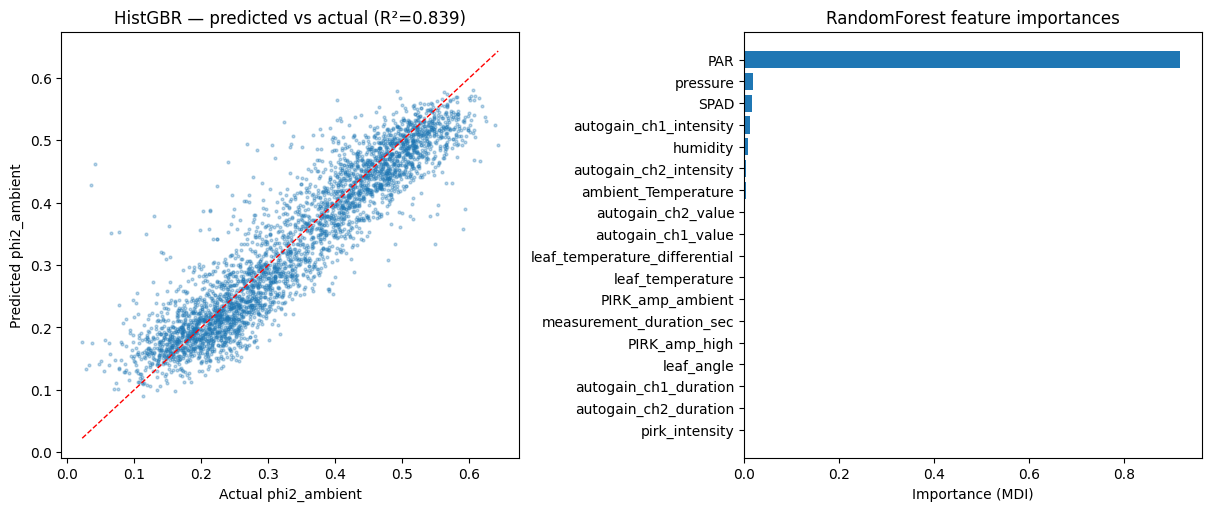

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

# Predicted vs actual for best tree model (HistGBR)
ax = axs[0]
ax.scatter(y, hgb_pred, s=4, alpha=0.3)
lims = [min(y.min(), hgb_pred.min()), max(y.max(), hgb_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set(
    xlabel="Actual phi2_ambient",
    ylabel="Predicted phi2_ambient",
    title=f"HistGBR — predicted vs actual (R²={hgb_scores.mean():.3f})",
)

# Feature importances (RandomForest)
ax = axs[1]
order = np.argsort(importances)
ax.barh([feature_cols[i] for i in order], importances[order])
ax.set(xlabel="Importance (MDI)", title="RandomForest feature importances")

plt.show()

## Part 2 — Fluorescence traces → Phi2

The `sample_raw` column contains time-resolved fluorescence data from the MultispeQ device.
We extract the **PAM-ABS** trace (ambient light, 660 data points) as a high-dimensional
feature vector and use it to predict `phi2_ambient`.

This is exactly the kind of problem where **PLS Regression** shines:
high-dimensional correlated inputs, small sample sizes, and interpretable latent components.
Photosynthesis researchers already use PLS in spectroscopy contexts.

In [40]:
def extract_trace(raw_json: str, set_index: int) -> list[float] | None:
    """Extract data_raw array from a specific set index in sample_raw."""
    try:
        parsed = json.loads(raw_json)
        data_raw = parsed[0]["set"][set_index].get("data_raw", [])
        if len(data_raw) > 0:
            return data_raw
    except (json.JSONDecodeError, IndexError, KeyError, TypeError):
        pass
    return None


# PAM-ABS ambient trace is at set[6] (660 points)
print("Extracting PAM-ABS ambient traces from sample_raw...")
traces = df.select(
    pl.col("sample_raw").map_elements(
        lambda x: extract_trace(x, set_index=6), return_dtype=pl.List(pl.Float64)
    )
)["sample_raw"]

# Filter out any failed extractions and build matrix
valid_mask = traces.map_elements(
    lambda x: x is not None and len(x) == 660, return_dtype=pl.Boolean
)
print(f"Valid traces: {valid_mask.sum()} / {df.height}")

X_trace = np.array(traces.filter(valid_mask).to_list())
y_trace = y[valid_mask.to_numpy()]

print(f"X_trace shape: {X_trace.shape}")
print(f"y_trace range: [{y_trace.min():.3f}, {y_trace.max():.3f}]")

Extracting PAM-ABS ambient traces from sample_raw...
Valid traces: 3681 / 3681
X_trace shape: (3681, 660)
y_trace range: [0.022, 0.643]


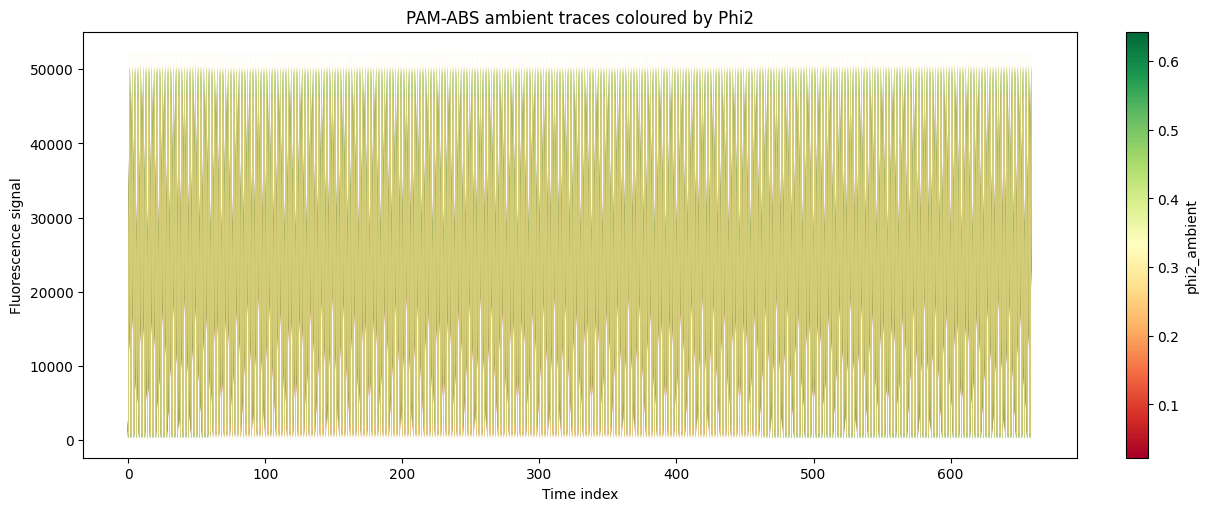

In [41]:
# Visualise a sample of traces, coloured by Phi2
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_trace), size=min(200, len(X_trace)), replace=False)

for i in sample_idx:
    color = plt.cm.RdYlGn(y_trace[i] / y_trace.max())
    ax.plot(X_trace[i], color=color, alpha=0.2, linewidth=0.5)

sm = plt.cm.ScalarMappable(
    cmap="RdYlGn", norm=plt.Normalize(y_trace.min(), y_trace.max())
)
fig.colorbar(sm, ax=ax, label="phi2_ambient")
ax.set(
    xlabel="Time index",
    ylabel="Fluorescence signal",
    title="PAM-ABS ambient traces coloured by Phi2",
)
plt.show()

### PLS Regression on traces

Partial Least Squares projects the 660-dimensional trace into a few latent components
that maximise covariance with the target. Ideal for correlated, high-dimensional inputs
with small sample sizes.

In [42]:
# Try different numbers of components to find the sweet spot
n_components_range = [2, 5, 10, 20, 30, 50]
pls_results = []

for n in n_components_range:
    pls = make_pipeline(StandardScaler(), PLSRegression(n_components=n))
    scores = cross_val_score(pls, X_trace, y_trace, cv=5, scoring="r2")
    pls_results.append((n, scores.mean(), scores.std()))
    print(f"  PLS(n={n:2d}) R² = {scores.mean():.3f} ± {scores.std():.3f}")

best_n = max(pls_results, key=lambda x: x[1])[0]
print(f"\nBest n_components: {best_n}")

  PLS(n= 2) R² = 0.705 ± 0.121
  PLS(n= 5) R² = 0.819 ± 0.072
  PLS(n=10) R² = 0.554 ± 0.733
  PLS(n=20) R² = 0.777 ± 0.317
  PLS(n=30) R² = 0.808 ± 0.238
  PLS(n=50) R² = 0.812 ± 0.229

Best n_components: 5


In [43]:
# Cross-validated predictions with best PLS
best_pls = make_pipeline(StandardScaler(), PLSRegression(n_components=best_n))
pls_pred = cross_val_predict(best_pls, X_trace, y_trace, cv=5)
pls_r2 = r2_score(y_trace, pls_pred)
pls_mae = mean_absolute_error(y_trace, pls_pred)

print(f"PLS(n={best_n}) — R²: {pls_r2:.3f}, MAE: {pls_mae:.4f}")

PLS(n=5) — R²: 0.846, MAE: 0.0348


### Ridge, ElasticNet, and RandomForest on traces

Ridge gives a baseline for how linear the trace→Phi2 relationship is.
**ElasticNet** (L1+L2 mix) handles correlated features much better than pure Lasso —
it groups correlated time points instead of arbitrarily selecting one.
**RandomForest** captures non-linear patterns in the trace shape.

In [44]:
# Ridge on traces (closed-form, no convergence issues)
ridge_trace = make_pipeline(
    StandardScaler(),
    RidgeCV(
        alphas=np.logspace(-2, 5, 20)
    ),  # wide range — traces need strong regularisation
)
ridge_trace_scores = cross_val_score(ridge_trace, X_trace, y_trace, cv=5, scoring="r2")
print(
    f"Ridge (traces)      R² = {ridge_trace_scores.mean():.3f} ± {ridge_trace_scores.std():.3f}"
)

# ElasticNet (L1+L2) — much better than pure Lasso for correlated features
elastic_trace = make_pipeline(
    StandardScaler(),
    ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=50_000),
)
elastic_trace_scores = cross_val_score(
    elastic_trace, X_trace, y_trace, cv=5, scoring="r2"
)
print(
    f"ElasticNet (traces) R² = {elastic_trace_scores.mean():.3f} ± {elastic_trace_scores.std():.3f}"
)

# RandomForest on traces — captures non-linear trace shape patterns
rf_trace = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
)
rf_trace_scores = cross_val_score(rf_trace, X_trace, y_trace, cv=5, scoring="r2")
print(
    f"RandomForest (traces) R² = {rf_trace_scores.mean():.3f} ± {rf_trace_scores.std():.3f}"
)

Ridge (traces)      R² = 0.644 ± 0.573


/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.619e-03, tolerance: 3.495e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.086e-03, tolerance: 3.719e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might w

ElasticNet (traces) R² = 0.822 ± 0.165
RandomForest (traces) R² = 0.958 ± 0.006


/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.844e-03, tolerance: 4.675e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.846e-02, tolerance: 4.675e-03
  model = cd_fast.enet_coordinate_descent_gram(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might w

ElasticNet selected 25 / 660 time points
Best l1_ratio: 0.90, best alpha: 0.0002


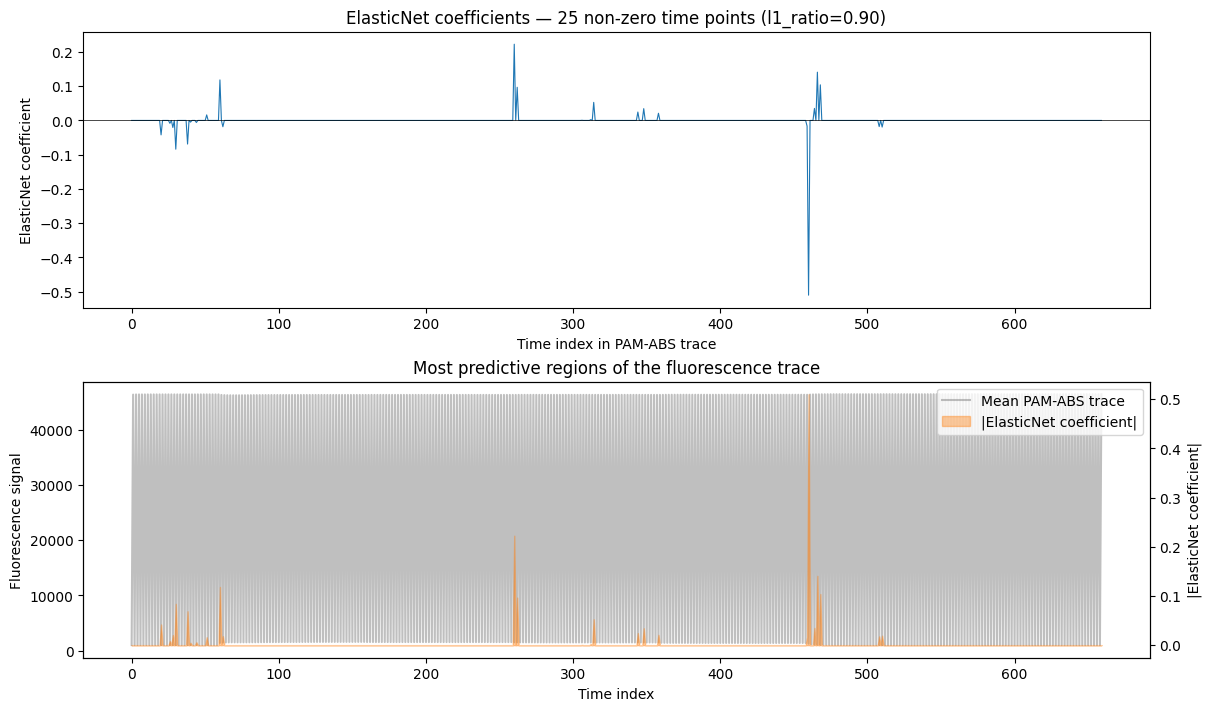

In [45]:
# Fit ElasticNet on full trace data to see which time points matter
elastic_trace.fit(X_trace, y_trace)
enet = elastic_trace.named_steps["elasticnetcv"]
trace_coefs = enet.coef_

n_nonzero = np.sum(np.abs(trace_coefs) > 1e-6)
print(f"ElasticNet selected {n_nonzero} / {len(trace_coefs)} time points")
print(f"Best l1_ratio: {enet.l1_ratio_:.2f}, best alpha: {enet.alpha_:.4f}")

fig, axs = plt.subplots(2, 1, figsize=(12, 7), layout="constrained")

# ElasticNet coefficients across the trace
ax = axs[0]
ax.plot(trace_coefs, linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set(
    xlabel="Time index in PAM-ABS trace",
    ylabel="ElasticNet coefficient",
    title=f"ElasticNet coefficients — {n_nonzero} non-zero time points (l1_ratio={enet.l1_ratio_:.2f})",
)

# Overlay on mean trace to show where the informative regions are
ax = axs[1]
mean_trace = X_trace.mean(axis=0)
ax.plot(mean_trace, color="gray", alpha=0.5, label="Mean PAM-ABS trace")
ax2 = ax.twinx()
ax2.fill_between(
    range(len(trace_coefs)),
    np.abs(trace_coefs),
    alpha=0.4,
    color="tab:orange",
    label="|ElasticNet coefficient|",
)
ax.set(xlabel="Time index", ylabel="Fluorescence signal")
ax2.set_ylabel("|ElasticNet coefficient|")
ax.set_title("Most predictive regions of the fluorescence trace")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

### Comparison of trace-based models

In [46]:
trace_results = pl.DataFrame(
    {
        "Model": [
            "Ridge (trace)",
            "ElasticNet (trace)",
            f"PLS (n={best_n})",
            "RandomForest (trace)",
        ],
        "R² mean": [
            ridge_trace_scores.mean(),
            elastic_trace_scores.mean(),
            pls_r2,
            rf_trace_scores.mean(),
        ],
        "R² std": [
            ridge_trace_scores.std(),
            elastic_trace_scores.std(),
            0.0,
            rf_trace_scores.std(),
        ],
    }
).sort("R² mean", descending=True)

print("PAM-ABS trace (660 features) → phi2_ambient (5-fold CV):")
trace_results

PAM-ABS trace (660 features) → phi2_ambient (5-fold CV):


Model,R² mean,R² std
str,f64,f64
"""RandomForest (trace)""",0.957777,0.006315
"""PLS (n=5)""",0.846052,0.0
"""ElasticNet (trace)""",0.821961,0.164701
"""Ridge (trace)""",0.644307,0.573432


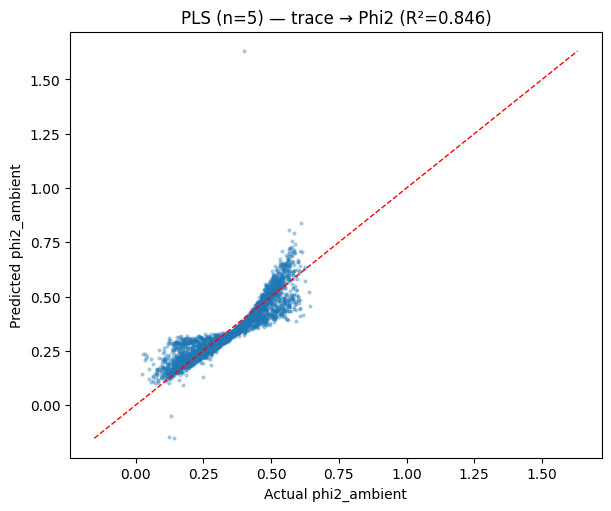

In [47]:
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.scatter(y_trace, pls_pred, s=4, alpha=0.3)
lims = [min(y_trace.min(), pls_pred.min()), max(y_trace.max(), pls_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set(
    xlabel="Actual phi2_ambient",
    ylabel="Predicted phi2_ambient",
    title=f"PLS (n={best_n}) — trace → Phi2 (R²={pls_r2:.3f})",
)
plt.show()

## Part 3 — Combined scalar + trace features

The scalar models (HistGBR R²≈0.84) and trace-based PLS (R²≈0.85) reach similar
performance from very different feature spaces. Combining them may capture
complementary information — environmental context from scalar features plus
fluorescence dynamics from the raw trace.

In [48]:
# Combine: 18 scalar features + 660 trace features = 678 features
# Use only measurements where we have valid traces
X_scalar_valid = df.filter(pl.lit(valid_mask)).select(feature_cols).to_numpy()
X_combined = np.hstack([X_scalar_valid, X_trace])
print(f"X_combined shape: {X_combined.shape}")

# HistGBR on combined — can handle the mixed feature scales natively
hgb_combined = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=10,
)
hgb_combined_scores = cross_val_score(
    hgb_combined, X_combined, y_trace, cv=5, scoring="r2"
)
print(
    f"HistGBR (combined)  R² = {hgb_combined_scores.mean():.3f} ± {hgb_combined_scores.std():.3f}"
)

# PLS on combined (after scaling)
pls_combined = make_pipeline(StandardScaler(), PLSRegression(n_components=best_n))
pls_combined_scores = cross_val_score(
    pls_combined, X_combined, y_trace, cv=5, scoring="r2"
)
print(
    f"PLS (combined)      R² = {pls_combined_scores.mean():.3f} ± {pls_combined_scores.std():.3f}"
)

# RF on combined
rf_combined = RandomForestRegressor(
    n_estimators=500, max_depth=10, min_samples_leaf=10, n_jobs=-1, random_state=42
)
rf_combined_scores = cross_val_score(
    rf_combined, X_combined, y_trace, cv=5, scoring="r2"
)
print(
    f"RF (combined)       R² = {rf_combined_scores.mean():.3f} ± {rf_combined_scores.std():.3f}"
)

X_combined shape: (3681, 678)
HistGBR (combined)  R² = 0.951 ± 0.019
PLS (combined)      R² = 0.871 ± 0.044
RF (combined)       R² = 0.891 ± 0.044


## Summary

All models compared side-by-side.

In [49]:
all_results = pl.DataFrame(
    {
        "Model": [
            "Ridge (scalar)",
            "Lasso (scalar)",
            "HistGBR (scalar)",
            "RandomForest (scalar)",
            "Ridge (trace)",
            "ElasticNet (trace)",
            f"PLS n={best_n} (trace)",
            "RandomForest (trace)",
            "HistGBR (combined)",
            "PLS (combined)",
            "RF (combined)",
        ],
        "Features": [
            f"{X_scalar.shape[1]} scalar",
            f"{X_scalar.shape[1]} scalar",
            f"{X_scalar.shape[1]} scalar",
            f"{X_scalar.shape[1]} scalar",
            f"{X_trace.shape[1]} trace",
            f"{X_trace.shape[1]} trace",
            f"{X_trace.shape[1]} trace",
            f"{X_trace.shape[1]} trace",
            f"{X_combined.shape[1]} combined",
            f"{X_combined.shape[1]} combined",
            f"{X_combined.shape[1]} combined",
        ],
        "R² (5-fold CV)": [
            f"{ridge_scores.mean():.3f} ± {ridge_scores.std():.3f}",
            f"{lasso_scores.mean():.3f} ± {lasso_scores.std():.3f}",
            f"{hgb_scores.mean():.3f} ± {hgb_scores.std():.3f}",
            f"{rf_scores.mean():.3f} ± {rf_scores.std():.3f}",
            f"{ridge_trace_scores.mean():.3f} ± {ridge_trace_scores.std():.3f}",
            f"{elastic_trace_scores.mean():.3f} ± {elastic_trace_scores.std():.3f}",
            f"{pls_r2:.3f}",
            f"{rf_trace_scores.mean():.3f} ± {rf_trace_scores.std():.3f}",
            f"{hgb_combined_scores.mean():.3f} ± {hgb_combined_scores.std():.3f}",
            f"{pls_combined_scores.mean():.3f} ± {pls_combined_scores.std():.3f}",
            f"{rf_combined_scores.mean():.3f} ± {rf_combined_scores.std():.3f}",
        ],
    }
)

all_results

Model,Features,R² (5-fold CV)
str,str,str
"""Ridge (scalar)""","""18 scalar""","""0.749 ± 0.103"""
"""Lasso (scalar)""","""18 scalar""","""0.749 ± 0.093"""
"""HistGBR (scalar)""","""18 scalar""","""0.839 ± 0.050"""
"""RandomForest (scalar)""","""18 scalar""","""0.825 ± 0.059"""
"""Ridge (trace)""","""660 trace""","""0.644 ± 0.573"""
…,…,…
"""PLS n=5 (trace)""","""660 trace""","""0.846"""
"""RandomForest (trace)""","""660 trace""","""0.958 ± 0.006"""
"""HistGBR (combined)""","""678 combined""","""0.951 ± 0.019"""
